In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
state_by_month_cps = pd.read_csv('/Users/chrisgee/UCSD2526/replication_project/data/state_by_month_cps.csv')
state_by_month_cps['PERIOD'] = pd.to_datetime(state_by_month_cps['PERIOD']).dt.to_period('M')
state_by_month_cps['EMPSTAT'] = state_by_month_cps['EMPSTAT'].isin([10, 11, 12]).astype('int')
state_by_month_cps

,Unnamed: 0,PERIOD,IND1990,EMPSTAT,ASECWT,WTFINL,DID_DUMMY,NJ_PA,POLICY_PERIOD
0,0,1988-01,0,0,NaN,1241.0400,0,1,0
1,1,1988-01,192,1,NaN,1537.2900,0,1,0
2,2,1988-01,910,1,NaN,1266.4100,0,1,0
3,3,1988-01,0,0,NaN,1288.7100,0,1,0
4,4,1988-01,0,0,NaN,1212.1600,0,1,0
...,...,...,...,...,...,...,...,...,...
1519211,1519211,1997-12,0,0,NaN,1892.5032,0,0,1
1519212,1519212,1997-12,0,0,NaN,2317.6384,0,0,1
1519213,1519213,1997-12,831,1,NaN,2039.9635,0,0,1
1519214,1519214,1997-12,60,1,NaN,2142.6876,0,0,1


In [50]:
# Filtering for CPS data points with following criterias:
# Working in 641 (eating and drinkiing places)
# Working (EMPSTAT = 1)
state_by_month_cps = state_by_month_cps[(state_by_month_cps['ASECWT'].isna() == True) & (state_by_month_cps['IND1990'] == 641)].reset_index()
# Aggregating to group weights of individuals for each period that met filtering criteria
state_by_month_cps_sum = state_by_month_cps[state_by_month_cps['EMPSTAT'] == 1]
state_by_month_cps_sum = state_by_month_cps_sum.groupby(['NJ_PA', 'PERIOD'])['WTFINL'].sum().reset_index()
state_by_month_cps_sum

,NJ_PA,PERIOD,WTFINL
0,0,1988-01,233245.2700
1,0,1988-02,206743.6300
2,0,1988-03,218862.5700
3,0,1988-04,243557.3800
4,0,1988-05,292737.9400
...,...,...,...
235,1,1997-08,195959.2994
236,1,1997-09,170358.7339
237,1,1997-10,179518.6538
238,1,1997-11,164377.2749


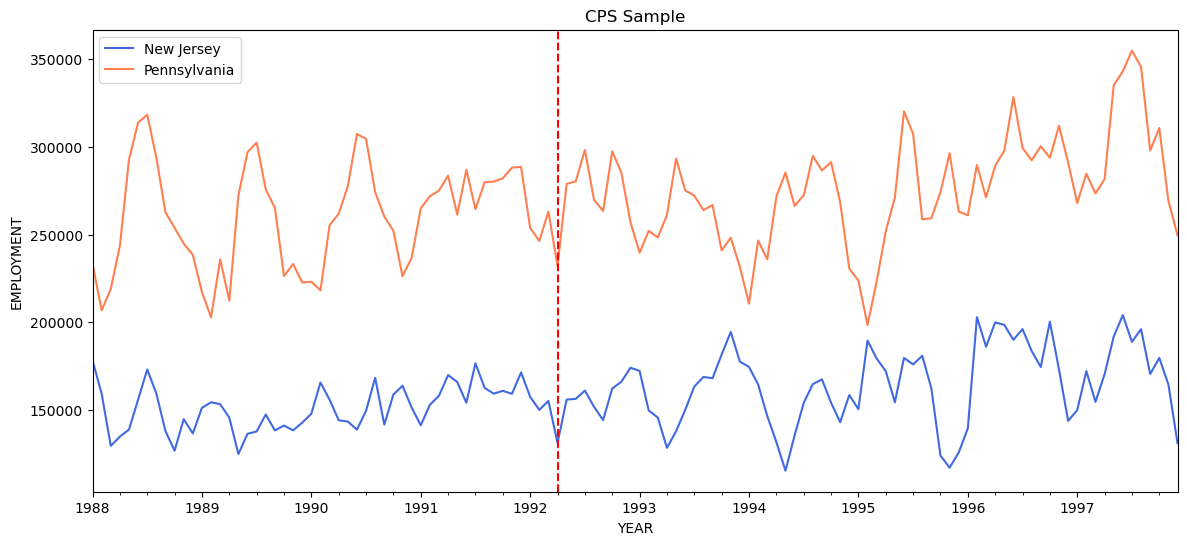

In [51]:
#Creating graph for employment totals at a state x monthly period for New Jersey and Pennsylvania
fig, ax = plt.subplots(figsize=(14, 6))

nj_state_by_month_cps = state_by_month_cps_sum[state_by_month_cps_sum.get('NJ_PA') == 1].set_index('PERIOD')
pa_state_by_month_cps = state_by_month_cps_sum[state_by_month_cps_sum.get('NJ_PA') == 0].set_index('PERIOD')

nj_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label = 'New Jersey', color ='royalblue');
pa_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label='Pennsylvania', color='coral');

period = pd.Period('1992-04', freq = 'M');
ax.axvline(x=period, color='red', linestyle='--', label='Vertical Line');
plt.xlabel('YEAR')
plt.ylabel('EMPLOYMENT')
ax.set_title('CPS Sample');
fig.savefig('/Users/chrisgee/UCSD2526/replication_project/output/CPS_641_EMPLOYMENT_1988_1998', dpi=300, bbox_inches='tight')

In [64]:
# Aggregating data to get proper yearly averages by state and employment status reported in the surveys
yearly_cps = state_by_month_cps.groupby(['PERIOD', 'NJ_PA', 'EMPSTAT'])['WTFINL'].sum().reset_index()
yearly_cps['PERIOD'] = yearly_cps['PERIOD'].dt.year
yearly_cps = yearly_cps.groupby(['PERIOD', 'NJ_PA', 'EMPSTAT'])['WTFINL'].mean().reset_index()
yearly_cps

,PERIOD,NJ_PA,EMPSTAT,WTFINL
0,1988,0,0,47073.064167
1,1988,0,1,260076.245833
2,1988,1,0,16823.201667
3,1988,1,1,147761.501667
4,1989,0,0,34729.659167
5,1989,0,1,246909.082500
6,1989,1,0,17015.949167
7,1989,1,1,142454.191667
8,1990,0,0,45980.511667
9,1990,0,1,258106.186667


In [72]:
# Pivoting the dataframe sp I can calculate the yearly employment based on the average weights calculated
yearly_cps_pivot = yearly_cps.pivot(
    index=['PERIOD', 'NJ_PA'], # Pivoting employment data around these 2 columns
    columns='EMPSTAT', # Category I'm rearranging 
    values='WTFINL' # Values that are shifting
).reset_index()
yearly_cps_pivot.columns = ['YEAR', 'NJ_PA', 'UNEMP', 'EMP']
yearly_cps_pivot = yearly_cps_pivot.assign(AVG_YEARLY_WTFINL = yearly_cps_pivot['EMP'] / (yearly_cps_pivot['EMP'] + yearly_cps_pivot['UNEMP']))
yearly_cps_pivot

,YEAR,NJ_PA,UNEMP,EMP,AVG_YEARLY_WTFINL
0,1988,0,47073.064167,260076.245833,0.846742
1,1988,1,16823.201667,147761.501667,0.897784
2,1989,0,34729.659167,246909.082500,0.876687
3,1989,1,17015.949167,142454.191667,0.893297
4,1990,0,45980.511667,258106.186667,0.848791
5,1990,1,19101.389167,152274.196667,0.888541
6,1991,0,48317.790833,277266.893333,0.851597
7,1991,1,22953.065000,160866.060833,0.875132
8,1992,0,49838.323333,268833.242500,0.843606
9,1992,1,27923.540833,155307.658333,0.847605


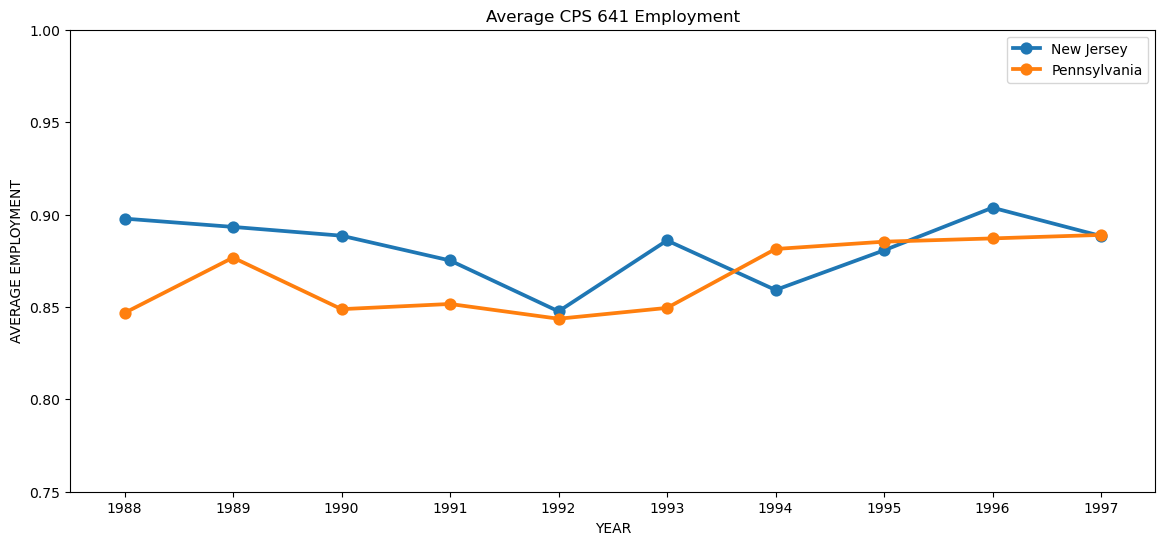

In [70]:
# Creating pointplot for average employment per year for New Jersey and Pennsylvania
fig, ax = plt.subplots(figsize=(14,6))


nj_yearly_cps_avg = yearly_cps_pivot[yearly_cps_pivot.get('NJ_PA') == 1]
pa_yearly_cps_avg = yearly_cps_pivot[yearly_cps_pivot.get('NJ_PA') == 0]

sns.pointplot(
    data=nj_yearly_cps_avg,
    x='YEAR',
    y='AVG_YEARLY_WTFINL',
    ax=ax,
    label='New Jersey'
)

sns.pointplot(
    data=pa_yearly_cps_avg,
    x='YEAR',
    y='AVG_YEARLY_WTFINL',
    ax=ax,
    label='Pennsylvania'
)
ax.set_title('Average CPS 641 Employment')
plt.ylabel('AVERAGE EMPLOYMENT')
plt.xlabel('YEAR')
plt.ylim(0.75, 1)
fig.savefig('/Users/chrisgee/UCSD2526/replication_project/output/CPS_641_AVG_EMPLOYMENT_1988_1998', dpi=300, bbox_inches='tight')